<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 9: *Fire Spread*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *Train Models*\
> *Generate Predictions*\
> *Geospatial Visualization*\
> *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios.


It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_spread`,`y_spread` ,`details_spread` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `spread_best_strategy` best class balancing strategies calculated from module 06
- `spread_model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `spread_predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json

# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

---

### Load Data

In [3]:
X_spread = pd.read_csv('../data/processed/X_spread.csv')
y_spread = pd.read_csv('../data/processed/y_spread.csv').squeeze()  # Load as Series
details_spread = pd.read_csv('../data/processed/details_spread.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/spread_best_strategy.csv')

with open('model_parameters_ignition.json', 'r') as f:
    model_parameters = json.load(f)

In [4]:
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details_spread['Date'] = pd.to_datetime(details_spread['Date']).dt.date

## Build Models

In [5]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build tuned models
spread_xgb = xgb.XGBClassifier(**XGB_parameters)
spread_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 15,
 'min_samples_split': 10,
 'max_features': 'log2',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 3,
 'n_estimators': 150,
 'max_depth': 3,
 'learning_rate': 0.4,
 'verbosity': 0}

## Train Models

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_spread, y_spread, test_size=0.2, random_state=14)

In [7]:
X_train_rf, y_train_rf = apply_balancing('RF', best_strategy, X_train, y_train)
X_train_xgb, y_train_xgb = apply_balancing('XGB', best_strategy, X_train, y_train)

spread_rf.fit(X_train_rf, y_train_rf)
spread_xgb.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.4, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

## Metrics

In [8]:
evaluate_model(spread_xgb, X_test, y_test, "Spread XGBoost")
evaluate_model(spread_rf, X_test, y_test, "Spread Random Forest")

Evaluation for Spread XGBoost
Accuracy:  0.843
Precision: 0.837
Recall:    0.843
F1 Score:  0.838


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      6052
           1       0.68      0.53      0.60      1040
           2       0.76      0.64      0.69      1075
           3       0.87      0.82      0.85      1090
           4       0.83      0.96      0.89       978

    accuracy                           0.84     10235
   macro avg       0.80      0.77      0.78     10235
weighted avg       0.84      0.84      0.84     10235



Evaluation for Spread Random Forest
Accuracy:  0.851
Precision: 0.868
Recall:    0.851
F1 Score:  0.854


---- Classification Report ----
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      6052
           1       0.62      0.78      0.69      1040
           2       0.73      0.84      0.78      1075
           3       0.8

In [9]:
# Create a Series for easy sorting
spread_rf_importances = pd.Series(spread_rf.feature_importances_, index=X_spread.columns)
spread_xgb_importances = pd.Series(spread_xgb.feature_importances_, index=X_spread.columns)

# Get top 10
spread_rf_top10 = spread_rf_importances.sort_values(ascending=False).head(10)
spread_xgb_top10 = spread_xgb_importances.sort_values(ascending=False).head(10)

rf_top10 = pd.DataFrame({
    'Random Forest': spread_rf_top10
})

xgb_top10 = pd.DataFrame({
    'XGBoost': spread_xgb_top10
})

display(rf_top10,xgb_top10)

,Random Forest
Palmer Drought Severity Index,0.041294
SPEI 90-Day,0.024823
SPEI 180-Day,0.023409
1000-hour Dead Fuel Moisture,0.022577
Solar Radiation 7 Day Avg,0.021951
road_density_x_forest_percent,0.021803
SPI 180-Day,0.021338
northness_mean_x_Daily Maximum Air Temperature,0.020252
slope_max,0.018766
forest_percent,0.018057


,XGBoost
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.140643
road_density_x_forest_percent,0.045523
Season_Fall,0.042361
Season_Winter,0.039196
slope_mean,0.027516
Season_Spring,0.025414
Season_Summer,0.020423
population_density,0.019814
dominant_section_description_Klamath Mountains,0.018218
dominant_province_description_California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow,0.017303


## Generate Case Study Predictions

In [10]:
pal_spread_xgb_predictions = pd.DataFrame(spread_xgb.predict(pal_X))
pal_spread_xgb_predictions.value_counts()

0
0    5306
4      63
3      43
1      14
2       2
Name: count, dtype: int64

In [11]:
pal_spread_rf_predictions = pd.DataFrame(spread_rf.predict(pal_X))
pal_spread_rf_predictions.value_counts()

0
0    5039
4     118
1     106
3      97
2      68
Name: count, dtype: int64

### Save Predictions for plotting

In [12]:
pal_details = pal_details.copy()

pal_details['Prediction Spread XGB'] = pal_spread_xgb_predictions[0].values

pal_details['Prediction Spread RF']  = pal_spread_rf_predictions[0].values

pal_details['Prediction Spread Actual'] = pal_y['Target_Spread']

#### Identify specific day to plot

In [13]:
pal_specific_date = pd.to_datetime('2025-01-08').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

#### Define geometries

In [14]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details['centroid_easting'], pal_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [15]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### Fire Spread Risk Predictions 
- Date: 01/07/2025

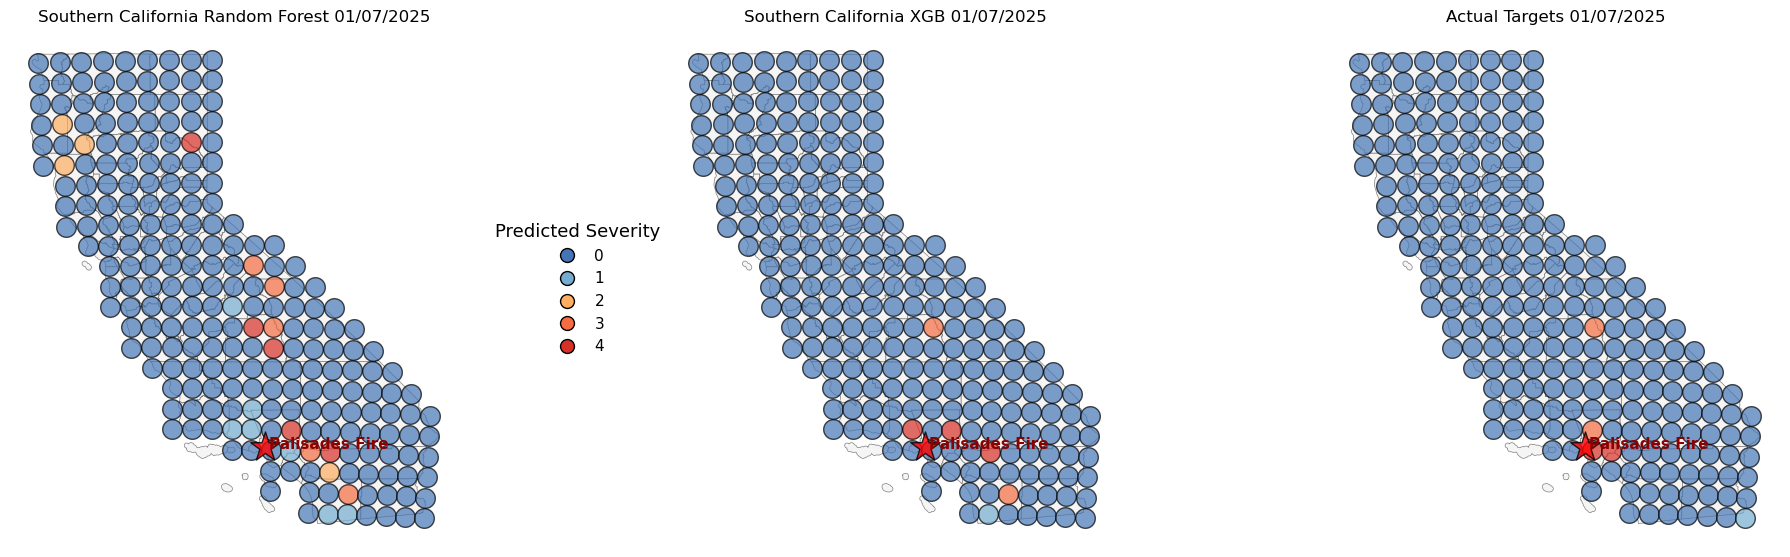

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction Spread RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Spread XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Spread Actual', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

plt.savefig("../plots/Palisades_predictions_subset.png", dpi=600)

## Export File

In [17]:
pal_gdf.to_csv('../data/processed/predictions_spread.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
